[Index](Index.ipynb) - [Prev](Qiskit_basics.ipynb) - [Next](Hadamard_gate.ipynb)

## Parameterised rotation gates <a id ='rotationgates'></a>

We will now play with other gates, the rotation gates. Rotation gates are parameterized gates, this means that the way they operate depends on a parameter (angle), which is given as an input. Parametrized gates are very useful because they allow us to manipulate the outcome of the circuit by tunning the parameters.

## RZ
Let us first try the $R_z$ gate. This gate is also known as the $R_\phi$ gate (since it is the $\phi$ angle in Bloch sphere that changes) and it is a rotation around the Z-axis. 

Before running the code

> Q1: What do you expect the output of a measurment is after rotating the qubit around the Z-axis?

In [9]:
# the quantum packages to import 
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer.primitives import SamplerV2
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, inset_axes

sampler = SamplerV2()

State of qubit after execution of Rz = [0.-1.j, 0.+0.j]


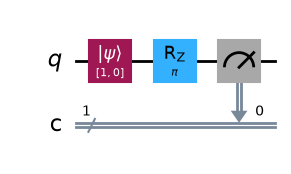

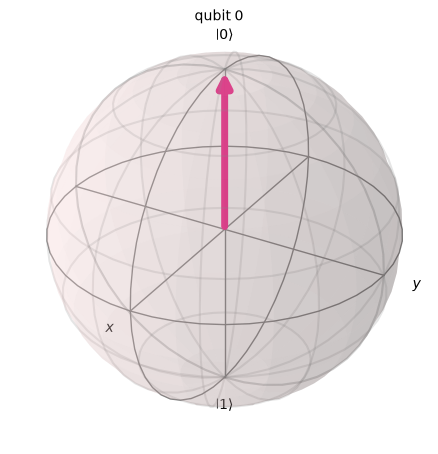

In [10]:
from math import pi
import numpy as np

#rotation angle in radians
angle = pi

#define circuit
q = QuantumRegister(1, 'q')
c = ClassicalRegister(1, 'c')
circuit = QuantumCircuit(q,c)

# Define initial_state alpha=1, beta=0 --> state |0>
initial_state = [1,0]   
circuit.initialize(initial_state, 0) 

# An R-phi rotation 180 degrees (pi radians)
circuit.rz(angle,q)

# get statevector
state = Statevector(circuit)
print("State of qubit after execution of Rz = " + np.array2string(np.round(state.data,3), separator=', '))

# Add a measurement to the circuit
circuit.measure(q,c)
#visualize crcuit
display(circuit.draw(output='mpl'))

# visualize state in bloch sphere
display(plot_bloch_multivector(state))

> E1: Comment the Rz gate and compare the result before the gate with the results after applying a gate.

> Q2: What has changed in the qubit state? Does this influence the measurment?

> E2: Uncomment the measurment and run the code again. What do you get?

## $R_x$ and $R_y$

Just as with the $R_z$, we can apply parameterized rotations in the Y and Z axis. 

> Q3: What measurment outcome do you expect after rotating the qubit on the X-axis by $\pi/2$? What about rotating on the Y-axis?

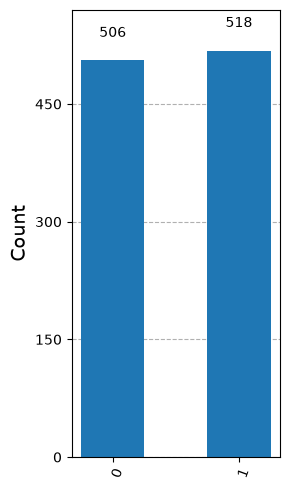

In [12]:
#rotation angle in radians
angle = pi/2


#define circuit
q = QuantumRegister(1, 'q')
c = ClassicalRegister(1, 'c')
circuit = QuantumCircuit(q,c)

# Define initial_state alpha=1, beta=0 --> state |0>
initial_state = [1,0]   
circuit.initialize(initial_state, 0) 

# A Rx rotation 90 degrees (pi/2 radians)
circuit.rx(angle,q)

# ---- Add extra gates to execute on qubit here----

# Add a measurement to the circuit
circuit.measure(q,c)

# execute the circuit
result = sampler.run([circuit]).result()
counts = result[0].data.c.get_counts()

# plot histogram
plot_histogram(counts,figsize=(3,5))

> Q4: What is the difference between applying an $R_x$ or an $R_y$ rotation? What changes in the qubit state? (hint: you might want to use the statevector_simulator backend to check this)

## S and T gates
Some rotations have their own name, for example:


- The S-gate (sometimes known as the $\sqrt Z$) is a rotation around the Z-axis ($R_z$ or $R_{\phi}$) with $\phi=\pi/2$

- The T-gate is a very commonly used gate, and is also a Z-axis rotation but by half the angle: $\phi=\pi/4$

> Q3: What happens if you apply two consecutive S gates or two consecutive T gates?

Circuits that have gates that depend on an parameter, eg. the angle, are called parametrized circuits. Parametrized circuits can be used for example to find the optimal solution of a problem. This is normally done by using a hybrid workflow where the optimization is done classically but the output is computed in a quanutm computer. The two work in tandem to find the solution to a problem. Examples of these type of algorithms are  the variational quantum eigensolver (VQE) and the quanutm approximate optimization algorithm (QAOA) (you will see more about this later)